# 06 · Phase 12 (part 1) — Classical reward oracle (logistic regression on configuration features)

The agent needs to know "how good is configuration *c* for recording *i*?". Training a CNN
per query is impossible (2,100 configurations × thousands of recordings), so a first reward
oracle is a **fast classical classifier**: standardised logistic regression on the configuration's
feature groups (Notebook 05).

* Training-split probabilities are **out-of-fold** (5-fold `StratifiedGroupKFold`, grouped by
  patient), so a recording is never scored by a model that saw it.
* Validation / test probabilities come from a model fit on the full training split.
* Identical feature sets are fitted once (e.g. every `T`-only configuration shares one model),
  giving 1,244 distinct classifiers.

**Per-recording reward** (p = probability of the true class, π = class prior of the training split):

| term | per-recording value | expectation over recordings |
|---|---|---|
| balanced | p · 0.5/π_y | balanced accuracy |
| sensitivity | 1[y=1] · p / π₁ | sensitivity |
| specificity | 1[y=0] · p / π₀ | specificity |
| robustness | balanced term on the 10 dB pink-noise copy | noisy balanced accuracy |
| complexity | 0.5·branches/3 + 0.3·level/5 + 0.2·window/4 s | compute cost |

r_i(c) = 0.40·bal + 0.25·sens + 0.20·spec + 0.10·rob − 0.05·cx, reported as **Δ vs the fixed
baseline configuration** (db6, L5, 20–800 Hz, 2 s, TSW) — the "Δ metric" form of the plan.
Because every term is an unbiased per-sample estimate of a population metric, maximising the
expected reward maximises the corresponding weighted metric. Macro-F1 is not decomposable per
sample, so it is used for policy *selection* rather than as the per-step reward.

The same reward definition is reused by the **deep** oracle of Notebook 07 (the primary oracle);
this classical oracle is kept as a comparison and as an RL ablation (Notebooks 14 and 17).

In [1]:
%run common/00_config.ipynb
%run common/01_signal_lib.ipynb
%run common/02_rl_lib.ipynb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

feats = joblib.load(P["processed"] / "config_features.joblib")
df = pd.read_csv(P["metadata"] / "records_qc.csv").set_index("record_id").loc[feats["record_id"]].reset_index()
space = ConfigSpace(CFG)
labelled = df.murmur_label.isin(["Present", "Absent"]).values
sel = np.where(labelled)[0]
F = {k: {g: v[sel] for g, v in feats[k].items()} for k in ("clean", "noisy")}
meta = df.iloc[sel][["record_id", "patient_id", "location", "split", "murmur_label", "outcome"]].reset_index(drop=True)
meta["y"] = (meta.murmur_label == "Present").astype(int)
y, groups = meta.y.values, meta.patient_id.values
tr, va, te = (np.where(meta.split == s)[0] for s in ("train", "val", "test"))
print(f"labelled recordings: {len(meta)} (train {len(tr)}, val {len(va)}, test {len(te)}); "
      f"unknown-murmur recordings excluded: {(~labelled).sum()}; train prevalence {y[tr].mean():.3f}")

ROOT = C:\Users\roshh\Desktop\rl
CirCor version = 1.0.3


loaded 01_signal_lib
loaded 02_rl_lib


labelled recordings: 3007 (train 2100, val 450, test 457); unknown-murmur recordings excluded: 156; train prevalence 0.167


In [2]:
t0 = time.time()
probs = proxy_probabilities(F, space, y, groups, tr, va, te, n_folds=5, seed=CFG["seed"])
print(f"fitted all proxy classifiers in {time.time() - t0:.0f}s")
np.savez_compressed(P["processed"] / "proxy_probs.npz",
                    **{f"{s}_{k}": probs[s][k] for s in probs for k in probs[s]})
meta.to_csv(P["processed"] / "proxy_records.csv", index=False)

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 21 concurrent workers.


[Parallel(n_jobs=-2)]: Done 120 tasks      | elapsed:   10.6s


[Parallel(n_jobs=-2)]: Done 323 tasks      | elapsed:   18.8s


[Parallel(n_jobs=-2)]: Done 606 tasks      | elapsed:   30.2s


[Parallel(n_jobs=-2)]: Done 971 tasks      | elapsed:   44.2s


[Parallel(n_jobs=-2)]: Done 1244 out of 1244 | elapsed:   53.6s finished


fitted all proxy classifiers in 54s


## How much does the configuration matter? (proxy, out-of-fold training split)

In [3]:
from sklearn.metrics import roc_auc_score
rows = []
for c in space.all_configs():
    p = probs["train"]["clean"][c]
    pn = probs["train"]["noisy"][c]
    m = binary_metrics(y[tr], p)
    rows.append({"config": c, **space.values(c), "oof_auroc": m["auroc"], "oof_bal_acc": m["balanced_acc"],
                 "oof_macro_f1": m["macro_f1"], "noisy_bal_acc": binary_metrics(y[tr], pn)["balanced_acc"]})
cfg_tab = pd.DataFrame(rows)
cfg_tab["band"] = cfg_tab.band.astype(str)
cfg_tab.to_csv(P["tables"] / "06_proxy_config_scores_train_oof.csv", index=False)
b = cfg_tab.loc[space.baseline]
print(f"baseline {space.label(space.baseline)}: OOF AUROC {b.oof_auroc:.3f}, BA {b.oof_bal_acc:.3f}")
print(f"best single config by OOF BA: {space.label(int(cfg_tab.oof_bal_acc.idxmax()))} -> {cfg_tab.oof_bal_acc.max():.3f}")
cfg_tab.sort_values("oof_bal_acc", ascending=False).head(10)

baseline db6-L5-20-800Hz-2.0s-TSW: OOF AUROC 0.764, BA 0.698
best single config by OOF BA: sym4-L3-400-800Hz-0.5s-TSW -> 0.759


,config,wavelet,level,band,window_s,fusion,oof_auroc,oof_bal_acc,oof_macro_f1,noisy_bal_acc
1350,1350,sym4,3,"(400, 800)",0.5,TSW,0.817016,0.758857,0.696649,0.604571
930,930,db8,3,"(400, 800)",0.5,TSW,0.817669,0.757714,0.694832,0.607714
510,510,db6,3,"(400, 800)",0.5,TSW,0.814036,0.753429,0.690757,0.612857
1768,1768,coif3,3,"(400, 800)",0.5,TW,0.811848,0.753143,0.686317,0.616857
1070,1070,db8,4,"(400, 800)",0.5,TSW,0.812044,0.752571,0.692086,0.609714
1490,1490,sym4,4,"(400, 800)",0.5,TSW,0.813107,0.752000,0.688514,0.629714
1910,1910,coif3,4,"(400, 800)",0.5,TSW,0.818016,0.748857,0.690230,0.620286
1770,1770,coif3,3,"(400, 800)",0.5,TSW,0.818168,0.748571,0.685806,0.602000
1488,1488,sym4,4,"(400, 800)",0.5,TW,0.811371,0.747429,0.684028,0.636857
965,965,db8,3,"(20, 800)",1.0,TSW,0.801887,0.747429,0.685341,0.606857


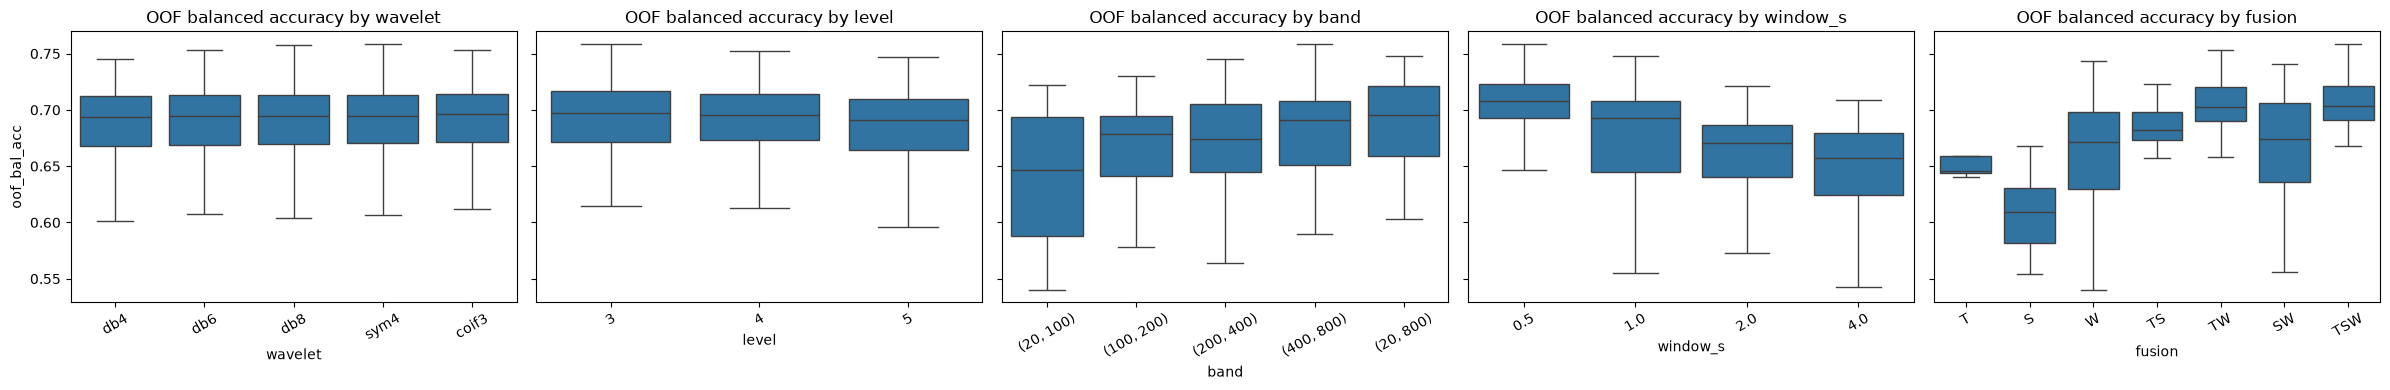

In [4]:
fig, ax = plt.subplots(1, 5, figsize=(24, 4), sharey=True)
for a, comp in zip(ax, ["wavelet", "level", "band", "window_s", "fusion"]):
    sub = cfg_tab if comp in ("band", "window_s", "fusion") else cfg_tab[cfg_tab.fusion.str.contains("W")]
    sns.boxplot(data=sub, x=comp, y="oof_bal_acc", ax=a, showfliers=False)
    a.set_title(f"OOF balanced accuracy by {comp}"); a.tick_params(axis="x", rotation=30)
plt.tight_layout(); savefig(fig, "06_config_component_effects"); plt.show()

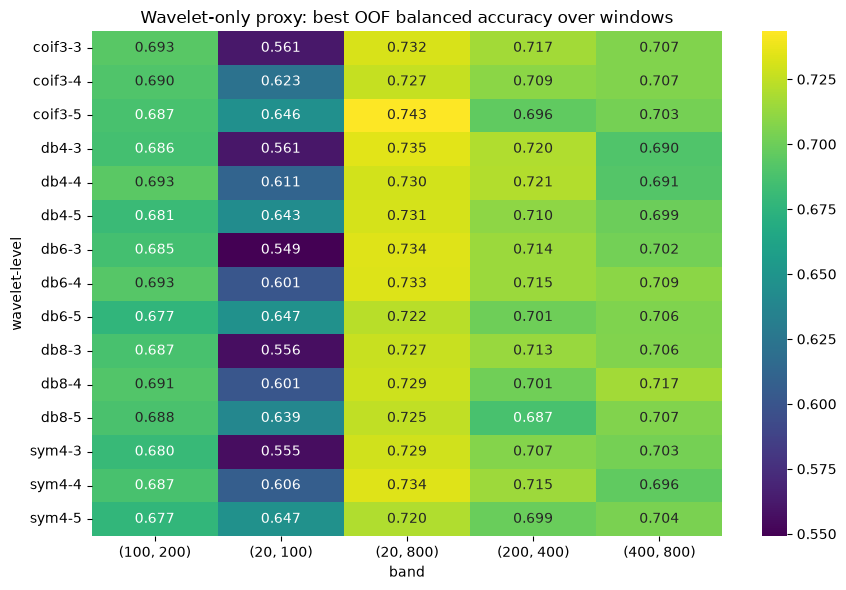

In [5]:
w = cfg_tab[cfg_tab.fusion == "W"].pivot_table(index=["wavelet", "level"], columns="band", values="oof_bal_acc", aggfunc="max")
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(w, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Wavelet-only proxy: best OOF balanced accuracy over windows")
plt.tight_layout(); savefig(fig, "06_wavelet_band_heatmap"); plt.show()

## Reward table sanity checks

E[balanced term] vs soft balanced accuracy of the baseline: 0.634 | check: 0.5*(soft sens + soft spec) = 0.634


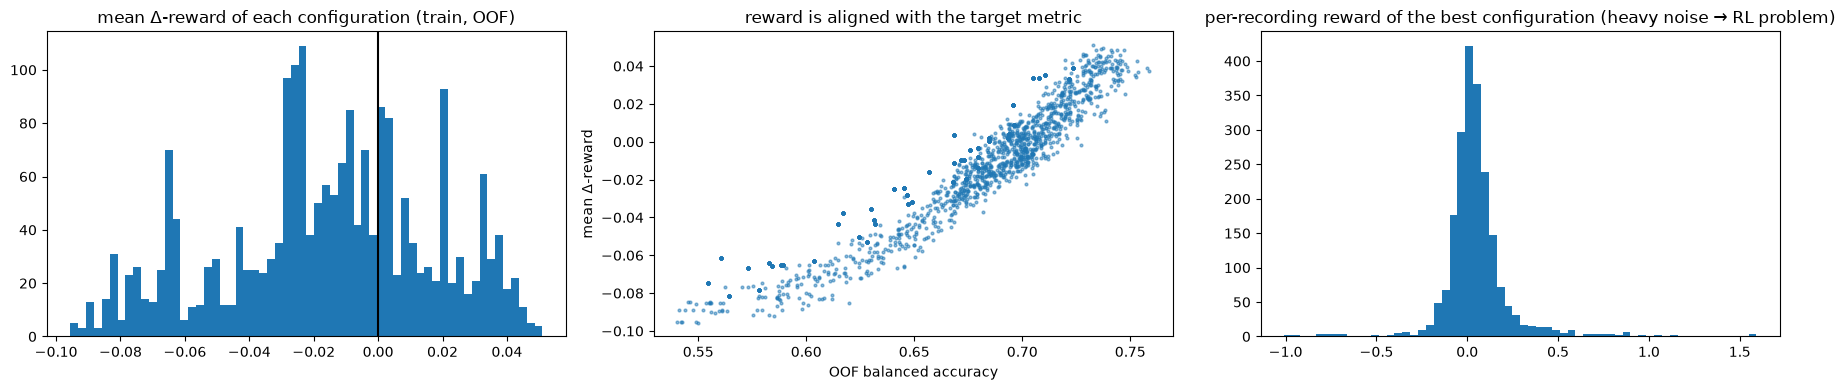

In [6]:
prior1 = y[tr].mean()
cx = np.array([space.complexity(c) for c in space.all_configs()])
comp = reward_components(probs["train"]["clean"], probs["train"]["noisy"], y[tr], prior1)
R = reward_table(comp, cx, CFG["reward"]["weights"], space.baseline)
soft_ba = comp["balanced"].mean(1)
print("E[balanced term] vs soft balanced accuracy of the baseline:",
      round(float(soft_ba[space.baseline]), 4),
      "| check: 0.5*(soft sens + soft spec) =", round(float(0.5 * (comp["sensitivity"].mean(1) + comp["specificity"].mean(1))[space.baseline]), 4))
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(R.mean(0), 60); ax[0].axvline(0, color="k"); ax[0].set_title("mean Δ-reward of each configuration (train, OOF)")
ax[1].scatter(cfg_tab.oof_bal_acc, R.mean(0), s=4, alpha=0.5); ax[1].set_xlabel("OOF balanced accuracy"); ax[1].set_ylabel("mean Δ-reward")
ax[1].set_title("reward is aligned with the target metric")
ax[2].hist(R[:, int(R.mean(0).argmax())], 60)
ax[2].set_title("per-recording reward of the best configuration (heavy noise → RL problem)")
plt.tight_layout(); savefig(fig, "06_reward_table"); plt.show()